# 泰勒展开与二阶导数

学习目标：用导数构造单变量与多变量的一阶、二阶近似，理解 Hessian 描述的局部曲率，并结合余项条件判断近似的误差与适用范围。

前置知识：单变量导数、梯度、雅可比矩阵、二次型；Python 函数和 NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11；函数与坐标均为无物理单位的教学例子。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 在线性近似上补一项弯曲变化

计算 $e^{0.1}$ 时，可以从容易计算的 $e^0=1$ 出发。函数 $f(x)=e^x$ 在零点的一阶、二阶导数都为 1。记 h 为从零点出发的实数增量，一阶近似为 $1+h$，加上二阶项后得到 $1+h+h^2/2$。

取 $h=0.1$，两种近似分别为 1.1 和 1.105。多出的 0.005 来自二阶导数；它补充了切线未表达的局部弯曲。先计算误差，再说明这个系数为何是二分之一。

In [1]:
import matplotlib.pyplot as plt
import numpy as np

h = 0.1
actual = np.exp(h)
linear = 1 + h
quadratic = 1 + h + h**2 / 2
print(f"函数值：{actual:.9f}")  # 预期约为 1.10517。
print(f"一阶近似：{linear:.9f}，绝对误差：{abs(actual - linear):.3e}")  # 预期约为 1.1，绝对误差：0.005171。
print(f"二阶近似：{quadratic:.9f}，绝对误差：{abs(actual - quadratic):.3e}")  # 预期约为 1.105，绝对误差：0.0001709。
# 本例二阶误差约 1.709e-4，小于一阶误差约 5.171e-3。

函数值：1.105170918
一阶近似：1.100000000，绝对误差：5.171e-03
二阶近似：1.105000000，绝对误差：1.709e-04


## 2 用同一点的导数确定多项式

设 a 为展开中心，$h=x-a$。希望多项式 $P_2(a+h)=c_0+c_1h+c_2h^2$ 在 a 处与 f 的函数值、一阶导数、二阶导数相同。逐次求导并令 h=0，得到

$$c_0=f(a),\qquad c_1=f'(a),\qquad 2c_2=f''(a).$$

因此二阶泰勒多项式（Taylor polynomial）为

$$P_2(a+h)=f(a)+f'(a)h+\frac12f''(a)h^2.$$

一般地，若 a 处存在到 n 阶的导数，n 为非负整数，则

$$P_n(a+h)=\sum_{k=0}^{n}\frac{f^{(k)}(a)}{k!}h^k.$$

这里 k 为求和索引，$f^{(0)}=f$，$f^{(k)}$ 表示 k 阶导数，$k!$ 为阶乘且 $0!=1$。中心 a=0 时也称麦克劳林多项式（Maclaurin polynomial）。能写出这些系数不等于已经控制了邻域内的误差。

例如 $f(x)=x^3$ 在 a=2 处的前三个系数是 8、12、6。直接展开 $(2+h)^3=8+12h+6h^2+h^3$，可看出二阶多项式遗漏的恰为 $h^3$。

In [2]:
a = 2.0
for h in (0.5, 0.1, -0.1):
    polynomial = 8 + 12 * h + 6 * h**2
    remainder = (a + h) ** 3 - polynomial
    print(f"h={h:+.1f}，二阶余项={remainder:+.6f}，h³={h**3:+.6f}")  # 三组余项等于 h³，依次为 0.125、0.001、-0.001。
# 这里有完整代数展开，余项公式无需由数值表来证明。

h=+0.5，二阶余项=+0.125000，h³=+0.125000
h=+0.1，二阶余项=+0.001000，h³=+0.001000
h=-0.1，二阶余项=-0.001000，h³=-0.001000


## 3 余项把近似改写成等式

定义余项 $R_n(a+h)=f(a+h)-P_n(a+h)$。若 f 在包含 a 与 a+h 的开区间上具有连续的 n+1 阶导数，泰勒定理给出某个介于两点之间的 $\xi$，使

$$R_n(a+h)=\frac{f^{(n+1)}(\xi)}{(n+1)!}h^{n+1}.$$

本章采用这个方便检查的充分条件。$\xi$ 通常未知，不能直接把它替换为 a。若沿两点间区间有 $|f^{(n+1)}(x)|\le M$，M 为非负上界，则

$$|R_n(a+h)|\le\frac{M}{(n+1)!}|h|^{n+1}.$$

例如对 $e^x$，在 $|h|\le0.5$ 内可统一取 $M=e^{0.5}$。一阶误差不超过 $Mh^2/2$，二阶误差不超过 $M|h|^3/6$。误差上界允许偏松，并非误差的预测值。

In [3]:
bound_derivative = np.exp(0.5)
for h in (-0.5, -0.1, 0.1, 0.5):
    error = abs(np.exp(h) - (1 + h + h**2 / 2))
    bound = bound_derivative * abs(h) ** 3 / 6
    # 四个“满足上界”均为 True；例如 h=0.5 时误差约 0.023721，小于界 0.034348。
    print(
        f"h={h:+.1f}，二阶误差={error:.6f}，上界={bound:.6f}，满足上界={error <= bound}"
    )
# 所列点均满足解析上界；有限个点的核对不是定理证明。

h=-0.5，二阶误差=0.018469，上界=0.034348，满足上界=True
h=-0.1，二阶误差=0.000163，上界=0.000275，满足上界=True
h=+0.1，二阶误差=0.000171，上界=0.000275，满足上界=True
h=+0.5，二阶误差=0.023721，上界=0.034348，满足上界=True


### 3.1 阶数描述的是靠近中心时的误差尺度

记号 $R(h)=O(|h|^p)$ 表示存在常数 C 和正数 δ，使 $0<|h|<\delta$ 时有 $|R(h)|\le C|h|^p$；p 为正数。它给出局部上界，不表示每次把 h 减半，实际误差都必须精确缩小 $2^p$ 倍。

上面的导数有界条件分别给出一阶近似误差 $O(h^2)$ 与二阶近似误差 $O(|h|^3)$。下面只取还未接近舍入误差尺度的正增量，观察本例误差比接近 4 与 8。

In [4]:
steps = np.array([0.2, 0.1, 0.05, 0.025])
values = np.exp(steps)
linear_errors = np.abs(values - (1 + steps))
quadratic_errors = np.abs(values - (1 + steps + steps**2 / 2))
print("步长：", steps)  # 预期约为 [0.2 0.1 0.05 0.025]。
print("一阶误差：", linear_errors)  # 预期约为 [0.0214028 0.00517092 0.0012711 0.00031512]。
print("二阶误差：", quadratic_errors)  # 预期约为 [0.00140276 0.000170918 2.10964e-05 2.62052e-06]。
print("一阶相邻误差比：", linear_errors[:-1] / linear_errors[1:])  # 预期约为 [4.13906 4.06808 4.03368]。
print("二阶相邻误差比：", quadratic_errors[:-1] / quadratic_errors[1:])  # 预期约为 [8.2072 8.10177 8.05044]。
# 极小步长下浮点相减可能丢失有效位，不应继续用此比值推断理论阶数。

步长： [0.2   0.1   0.05  0.025]
一阶误差： [0.02140276 0.00517092 0.0012711  0.00031512]
二阶误差： [1.40275816e-03 1.70918076e-04 2.10963760e-05 2.62052443e-06]
一阶相邻误差比： [4.13906348 4.06807711 4.03368323]
二阶相邻误差比： [8.20719608 8.10177423 8.05044051]


## 4 二阶近似仍然是局部近似

左图比较 $e^x$ 与零点的一阶、二阶多项式，右图给出绝对误差。两幅图都使用同一个展开中心；曲线重合只是绘图精度下的现象，误差由右图单独显示。

有限阶近似与无穷泰勒级数不同。若考虑阶数 n 趋于无穷，级数是否等于原函数还需要相应余项趋于零，不能仅凭“能求出所有阶导数”下结论。

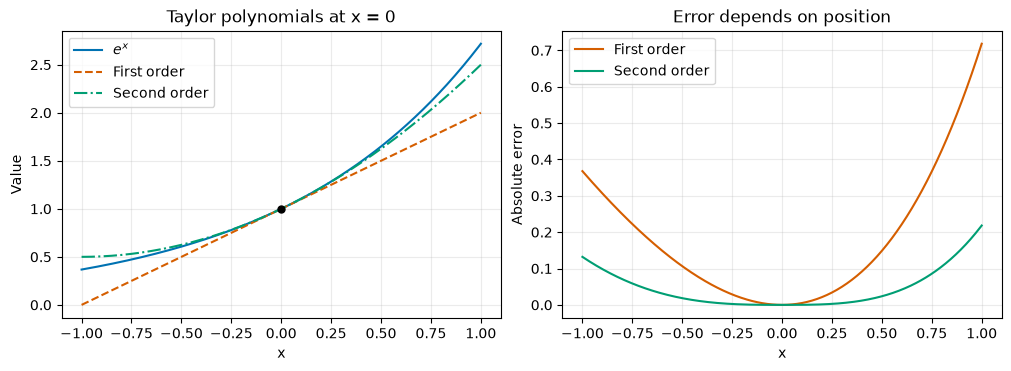

In [5]:
# 原函数与一、二阶多项式在同一网格计算，展开中心固定为 0。
x = np.linspace(-1, 1, 401)
function_values = np.exp(x)
first_values = 1 + x
second_values = 1 + x + x**2 / 2
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
axes[0].plot(x, function_values, color="#0072B2", label=r"$e^x$")
axes[0].plot(x, first_values, "--", color="#D55E00", label="First order")
axes[0].plot(x, second_values, "-.", color="#009E73", label="Second order")
axes[0].scatter([0], [1], color="black", s=25, zorder=3)
axes[0].set(xlabel="x", ylabel="Value", title="Taylor polynomials at x = 0")
# 右图直接画绝对误差，便于辨认左图中靠得很近的曲线。
axes[1].plot(
    x, abs(function_values - first_values), color="#D55E00", label="First order"
)
axes[1].plot(
    x, abs(function_values - second_values), color="#009E73", label="Second order"
)
axes[1].set(xlabel="x", ylabel="Absolute error", title="Error depends on position")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
# 中心处误差为零；本例在所画区间内二阶误差较小，但这不是对任意函数的全局结论。
plt.show()

### 4.1 远离中心时，增加一项可能变差

对 $f(x)=\ln(1+x)$，定义域为 $x>-1$，零点的一阶与二阶多项式为 $P_1(x)=x$、$P_2(x)=x-x^2/2$。取 x=3 时，二阶近似甚至小于零，而真实值为正。

函数在从 0 到 3 的区间仍然光滑，有限阶泰勒公式仍成立；只是增量不小，余项未必小。另一个边界是定义域：x≤−1 时，原实函数无定义，不能用多项式给它补一个函数值。

In [6]:
for x in (0.1, 0.5, 3.0):
    actual = np.log1p(x)
    first = x
    second = x - x**2 / 2
    # x=0.1、0.5 时二阶更准；x=3 时二阶误差约 2.8863，反而大于一阶的 1.6137。
    print(
        f"x={x:.1f}，一阶误差={abs(actual - first):.6f}，二阶误差={abs(actual - second):.6f}"
    )
# x=3 时二阶误差约 2.886，大于一阶误差约 1.614。

x=0.1，一阶误差=0.004690，二阶误差=0.000310
x=0.5，一阶误差=0.094535，二阶误差=0.030465
x=3.0，一阶误差=1.613706，二阶误差=2.886294


## 5 二阶偏导与 Hessian 矩阵

对实值函数 $f:\mathbb R^n\to\mathbb R$，n 为正整数，采用列梯度 $\nabla f\in\mathbb R^{n\times1}$。再次对梯度求雅可比，得到 Hessian 矩阵（海森矩阵）$H_f\in\mathbb R^{n\times n}$。其第 i 行、第 j 列定义为

$$[H_f(\mathbf{x})]_{ij}=\frac{\partial}{\partial x_j}
\left(\frac{\partial f}{\partial x_i}\right)(\mathbf{x}),\qquad i,j=1,\ldots,n.$$

二维时，本章记 $f_{xy}=\partial(f_x)/\partial y$，即先对 x 求导，再对 y 求导，因此

$$H_f(x,y)=\begin{pmatrix}f_{xx}&f_{xy}\\f_{yx}&f_{yy}\end{pmatrix}.$$

若二阶混合偏导在考察点的一个邻域内连续，则 $f_{xy}=f_{yx}$；这使 Hessian 对称。连续性是常用充分条件，不能仅因写出了两个混合偏导就自行交换次序。

取 $f(x,y)=x^2+xy+2y^2+x^3$，先求 $f_x=2x+y+3x^2$、$f_y=x+4y$，再逐项求导得到

$$H_f(x,y)=\begin{pmatrix}2+6x&1\\1&4\end{pmatrix}.$$

In [7]:
x, y = 0.0, 0.0
gradient = np.array([2 * x + y + 3 * x**2, x + 4 * y])
hessian = np.array([[2 + 6 * x, 1.0], [1.0, 4.0]])
print("梯度数组与形状：", gradient, gradient.shape)  # 预期为 [0. 0.] (2,)。
print("Hessian：", hessian, sep="\n")  # 预期为 [[2. 1.] [1. 4.]]。
print("Hessian 形状与对称性：", hessian.shape, np.array_equal(hessian, hessian.T))  # 预期为 (2, 2) True。
# 一维数组 (2,) 保存数学列梯度；Hessian 保留二维 (2, 2) 形状。

梯度数组与形状： [0. 0.] (2,)
Hessian：
[[2. 1.]
 [1. 4.]]
Hessian 形状与对称性： (2, 2) True


## 6 多变量泰勒公式的二次项

设 $\mathbf{a}\in\mathbb R^n$ 为展开中心，$\mathbf{h}\in\mathbb R^n$ 为列增量，f 在 a 的一个开球内具有连续的二阶偏导，记为 $f\in C^2$。足够小的 h 使整条线段留在这个球内，则

$$f(\mathbf{a}+\mathbf{h})=f(\mathbf{a})+\nabla f(\mathbf{a})^T\mathbf{h}
+\frac12\mathbf{h}^TH_f(\mathbf{a})\mathbf{h}+r(\mathbf{h}),$$

其中 $r(\mathbf{h})/\|\mathbf{h}\|_2^2\to0$，也写作 $r(\mathbf{h})=o(\|\mathbf{h}\|_2^2)$。小 o 要求比值趋于零；这比同尺度有界的 O 更强，但仅有 $C^2$ 条件时，不应直接把余项写成三次阶上界。

二维时，二次项展开为

$$\frac12\left(f_{xx}(\mathbf{a})h_1^2+2f_{xy}(\mathbf{a})h_1h_2+f_{yy}(\mathbf{a})h_2^2\right).$$

系数 2 来自矩阵乘法里的两个混合项，不可遗漏。只保留对角元素，会漏掉两个输入共同改变时的相互影响。

In [8]:
delta = np.array([0.1, 0.2])
hessian = np.array([[2.0, 1.0], [1.0, 4.0]])
matrix_term = 0.5 * delta @ hessian @ delta
expanded_term = 0.5 * (2 * delta[0] ** 2 + 2 * delta[0] * delta[1] + 4 * delta[1] ** 2)
diagonal_only = 0.5 * np.sum(np.diag(hessian) * delta**2)
print("矩阵二次项：", matrix_term)  # 0.11。
print("逐项二次项：", expanded_term)  # 0.11。
print("遗漏混合项后的值：", diagonal_only)  # 0.09，少了 0.02。

矩阵二次项： 0.11000000000000001
逐项二次项： 0.11000000000000001
遗漏混合项后的值： 0.09000000000000002


### 6.1 沿线段把多变量问题化为单变量问题

固定一个足够小的 h，令 $g(t)=f(\mathbf{a}+t\mathbf{h})$，$0\le t\le1$。链式法则给出

$$g'(0)=\nabla f(\mathbf{a})^T\mathbf{h},\qquad
g''(t)=\mathbf{h}^TH_f(\mathbf{a}+t\mathbf{h})\mathbf{h}.$$

对 g 在 0 与 1 之间应用一阶泰勒定理，存在 $\theta\in(0,1)$，使

$$f(\mathbf{a}+\mathbf{h})=f(\mathbf{a})+\nabla f(\mathbf{a})^T\mathbf{h}
+\frac12\mathbf{h}^TH_f(\mathbf{a}+\theta\mathbf{h})\mathbf{h}.$$

将最后的 Hessian 拆成中心处的矩阵与差值，就得到二阶近似和余项。若 E 是两个 Hessian 的差，则 $|h_i|\le\|\mathbf{h}\|_2$ 给出

$$\frac{|r(\mathbf{h})|}{\|\mathbf{h}\|_2^2}
\le\frac{n^2}{2}\max_{i,j}|E_{ij}|\longrightarrow0.$$

这里的极限来自 Hessian 各元素在 a 处连续，且线段上的点也趋近 a；因此结论覆盖所有趋近方向。这个推导也指出：公式中的 Hessian 应在中心处求值，不能把未知的中间点当作已知输入。

对刚才的多项式，在中心 $(0,0)^T$ 处，二阶近似为 $x^2+xy+2y^2$，余项正是 $x^3$。

In [9]:
for scale in (0.2, 0.1, 0.05):
    delta = scale * np.array([0.6, -0.8])
    x, y = delta
    actual = x**2 + x * y + 2 * y**2 + x**3
    prediction = 0.5 * delta @ hessian @ delta
    remainder = actual - prediction
    # 长度每减半，余项约变为 1/8；归一化余项依次为 0.0432、0.0216、0.0108。
    print(
        f"长度={scale:.2f}，余项={remainder:.6e}，余项/长度²={remainder / scale**2:.6f}"
    )
# 方向已单位化，余项/长度² = 0.216 * scale，故按理论随 scale 趋零。

长度=0.20，余项=1.728000e-03，余项/长度²=0.043200
长度=0.10，余项=2.160000e-04，余项/长度²=0.021600
长度=0.05，余项=2.700000e-05，余项/长度²=0.010800


## 7 二阶方向导数描述局部曲率

令 u 为单位列向量，$\|u\|_2=1$，沿直线定义 $\phi(t)=f(\mathbf{a}+tu)$。在前述光滑条件下，

$$\phi'(0)=\nabla f(\mathbf{a})^Tu,\qquad
\phi''(0)=u^TH_f(\mathbf{a})u.$$

一阶导数描述当前斜率，二阶导数描述斜率怎样改变。本章“曲率”指这个方向二阶导数，不是曲线几何学中另外归一化的弧长曲率。比较方向时使用单位 u，避免把移动速度差异当成弯曲程度差异。

若 u 是对称 Hessian 的单位特征向量，$H_fu=\lambda u$，则 $u^TH_fu=\lambda$。在任意单位方向，将 u 展开为正交单位特征向量的组合，就得到各特征值的加权平均，权重为展开系数的平方且总和为 1。

因此最大与最小特征值分别是最大的与最小的方向二阶导数。以 $H=\begin{pmatrix}2&1\\1&4\end{pmatrix}$ 为例，两者为 $3\pm\sqrt2$。

In [10]:
eigenvalues, eigenvectors = np.linalg.eigh(hessian)
print("从小到大的特征值：", eigenvalues)  # 预期约为 [1.58579 4.41421]。
for index in range(2):
    direction = eigenvectors[:, index]
    curvature = direction @ hessian @ direction
    residual = np.linalg.norm(hessian @ direction - eigenvalues[index] * direction)
    # 两方向二阶导数约为 1.585786、4.414214；特征对残差均接近 0。
    print(
        f"方向 {index + 1}：{direction}，二阶导数={curvature:.6f}，特征对残差={residual:.2e}"
    )
# 特征向量允许整体变号；这不会改变二次型和方向二阶导数。

从小到大的特征值： [1.58578644 4.41421356]
方向 1：[-0.92387953  0.38268343]，二阶导数=1.585786，特征对残差=2.22e-16
方向 2：[0.38268343 0.92387953]，二阶导数=4.414214，特征对残差=0.00e+00


### 7.1 用二次曲线比较两个方向

为了单独观察二阶效应，画出二次函数 $q(\mathbf{h})=\tfrac12\mathbf{h}^TH\mathbf{h}$ 沿两个单位特征方向的截线。它们在原点的一阶导数都为零，但二阶导数不同。

这里 q 恰好是二次函数，所以截线精确等于 $\lambda t^2/2$。对一般非二次函数，Hessian 只描述考察点附近的二阶行为；一个点的 Hessian 无法单独说明任意远处的函数形状。

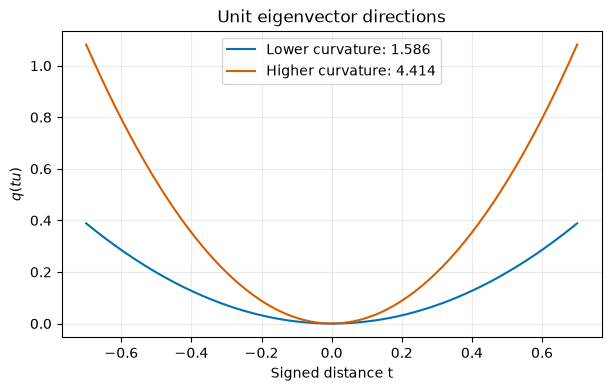

In [11]:
t = np.linspace(-0.7, 0.7, 201)
fig, ax = plt.subplots(figsize=(6, 3.8), layout="constrained")
for value, color, label in zip(
    eigenvalues, ["#0072B2", "#D55E00"], ["Lower curvature", "Higher curvature"]
):
    ax.plot(t, value * t**2 / 2, color=color, label=f"{label}: {value:.3f}")
ax.set(
    xlabel="Signed distance t", ylabel=r"$q(tu)$", title="Unit eigenvector directions"
)
ax.grid(alpha=0.25)
ax.legend()
# 相同移动距离下，较大的正特征值对应更快增加的二次变化。
plt.show()

## 8 综合应用：给二维近似选择范围

考虑自制函数

$$F(x,y)=e^{x+y}+x^2+2y^2,\qquad(x,y)\in\mathbb R^2,$$

在原点展开。逐项求导可得

$$F(0,0)=1,\qquad \nabla F(0,0)=\begin{pmatrix}1\\1\end{pmatrix},\qquad
H_F(0,0)=\begin{pmatrix}3&1\\1&5\end{pmatrix}.$$

一阶近似为 $P_1=1+x+y$，二阶近似为

$$P_2=1+x+y+\frac32x^2+xy+\frac52y^2.$$

下面同时用矩阵形式与展开形式计算，再直接代入 F 核对误差。输入和输出均无单位，误差标准按本例的函数值尺度选取。

In [12]:
def model(x, y):
    return np.exp(x + y) + x**2 + 2 * y**2


center_gradient = np.array([1.0, 1.0])
center_hessian = np.array([[3.0, 1.0], [1.0, 5.0]])
delta = np.array([0.1, 0.2])
x, y = delta
first = 1 + center_gradient @ delta
second = first + 0.5 * delta @ center_hessian @ delta
expanded = 1 + x + y + 1.5 * x**2 + x * y + 2.5 * y**2
actual = model(x, y)
print("真实值、一阶、二阶：", actual, first, second)  # 预期约为 1.43986 1.3 1.435。
print("二阶矩阵式与展开式之差：", second - expanded)  # 预期接近 0；本次计算为 0。
print("两种绝对误差：", abs(actual - first), abs(actual - second))  # 预期约为 0.139859 0.00485881。
# 在 (0.1, 0.2)，二阶结果为 1.435，真实值约 1.439859。

真实值、一阶、二阶： 1.4398588075760033 1.3 1.435
二阶矩阵式与展开式之差： 0.0
两种绝对误差： 0.13985880757600322 0.00485880757600321


### 8.1 用解析余项约束整个区域

令 $s=x+y$。本例的二次多项式部分已经精确保留，剩余误差全部来自指数项：

$$F-P_2=e^s-1-s-s^2/2.$$

若限制在正方形 $|x|\le r,|y|\le r$，r 为正半边长，则 $|s|\le2r$。指数函数的单变量泰勒余项界给出

$$|F-P_2|\le \frac{e^{2r}(2r)^3}{6}.$$

这条上界适用于整个正方形。若要求绝对误差不超过 0.01，可比较候选 r 的界再选范围。网格最大误差只是有限采样结果，不能替代覆盖整个区域的解析界。

In [13]:
tolerance = 0.01
for radius in (0.1, 0.2, 0.3):
    coordinates = np.linspace(-radius, radius, 101)
    x_grid, y_grid = np.meshgrid(coordinates, coordinates)
    second_grid = (
        1 + x_grid + y_grid + 1.5 * x_grid**2 + x_grid * y_grid + 2.5 * y_grid**2
    )
    sampled_error = np.max(abs(model(x_grid, y_grid) - second_grid))
    uniform_bound = np.exp(2 * radius) * (2 * radius) ** 3 / 6
    # r=0.1 的保证为 True；r=0.2、0.3 为 False，虽网格误差小于各自解析界。
    print(
        f"r={radius:.1f}，网格最大误差={sampled_error:.6f}，解析界={uniform_bound:.6f}，保证达标={uniform_bound <= tolerance}"
    )
# r=0.1 的解析界约 0.001629，可保证要求；较大候选不能由这些界保证达标。

r=0.1，网格最大误差=0.001403，解析界=0.001629，保证达标=True
r=0.2，网格最大误差=0.011825，解析界=0.015913，保证达标=False
r=0.3，网格最大误差=0.042119，解析界=0.065596，保证达标=False


### 8.2 误差还会随方向改变

沿 y=−x，指数项恒为 1，所以二阶近似在这条直线上恰好精确。这是本例的代数特性，不能仅凭某一方向的零误差就判断整个二维区域都精确。

画出正方形 $[-0.3,0.3]^2$ 内两种近似的绝对误差，使用相同颜色刻度。横纵坐标是输入 x、y，等高线表示相同误差；白色虚线标出 y=−x，黑点为展开中心。

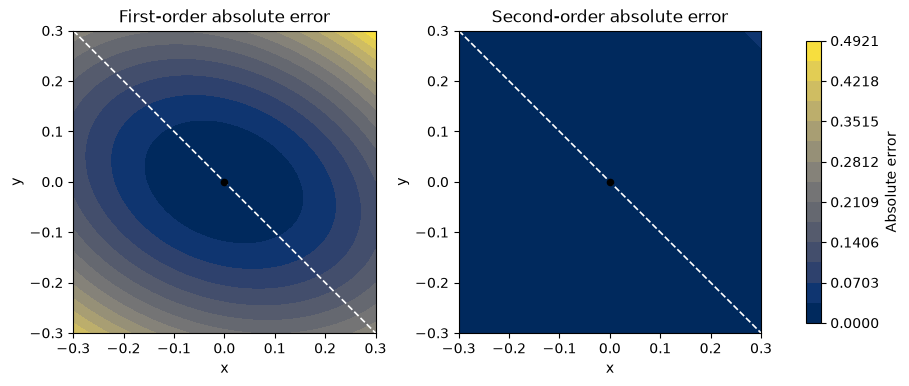

(x,y)=(0.1,-0.1)，二阶误差=2.22e-16
(x,y)=(0.5,-0.5)，二阶误差=0.00e+00
(x,y)=(1.0,-1.0)，二阶误差=0.00e+00


In [14]:
# 在二维网格逐点求误差，两幅图共用相同 levels 和色条。
coordinates = np.linspace(-0.3, 0.3, 151)
x_grid, y_grid = np.meshgrid(coordinates, coordinates)
actual_grid = model(x_grid, y_grid)
first_grid = 1 + x_grid + y_grid
second_grid = first_grid + 1.5 * x_grid**2 + x_grid * y_grid + 2.5 * y_grid**2
errors = [abs(actual_grid - first_grid), abs(actual_grid - second_grid)]
levels = np.linspace(0, max(error.max() for error in errors), 15)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), layout="constrained")
for ax, error, title in zip(
    axes, errors, ["First-order absolute error", "Second-order absolute error"]
):
    contour = ax.contourf(x_grid, y_grid, error, levels=levels, cmap="cividis")
    # 白色虚线表示 y=-x，用来观察本例沿这个方向的特殊余项。
    ax.plot(coordinates, -coordinates, "w--", linewidth=1.2)
    ax.scatter([0], [0], color="black", s=20, zorder=3)
    ax.set(xlabel="x", ylabel="y", title=title, aspect="equal")
fig.colorbar(contour, ax=axes, label="Absolute error", shrink=0.85)
# 两图同色代表同样的误差；右图沿虚线的误差在数学上为零。
plt.show()

# 从虚线方向另取三点，核对图中现象对应的数值。
for x in (0.1, 0.5, 1.0):
    y = -x
    prediction = 1 + x + y + 1.5 * x**2 + x * y + 2.5 * y**2
    print(f"(x,y)=({x:.1f},{y:.1f})，二阶误差={abs(model(x, y) - prediction):.2e}")  # 这三个点的二阶误差均接近 0，本次最大约 2.2e-16。

## 本章小结

（1）泰勒多项式在展开中心匹配导数。二阶项带有二分之一，来自二次项的二阶导数系数；不能省略这个因子。

（2）余项将近似写成等式。高阶导数界能给出指定区间的误差上界；增加阶数不保证远处一定更准，也不能越过原函数的定义域。

（3）Hessian 是列梯度的雅可比，连续二阶偏导保证其对称。二次型包含混合项，单位方向上的二阶导数为 Hessian 的二次型值。

（4）多变量二阶近似在连续二阶偏导条件下具有小于增量平方尺度的余项。实际范围应结合误差标准、方向和解析界判断，不能由单条曲线或有限网格代替条件分析。

自查：能否解释混合项前的 2？能否区分误差、误差上界和网格最大误差？能否说明为什么沿某条直线精确仍不足以保证整个邻域精确？

## 练习

（1）对 $f(x)=\sqrt{x}$ 在 a=4 处写出一阶与二阶泰勒多项式，分别估计 $\sqrt{4.1}$ 与 $\sqrt5$。先手算导数和系数，再与 NumPy 计算结果比较；写清余项定理需要覆盖的区间和定义域。

In [15]:
center = 4.0
increments = [0.1, 1.0]
# 补充：导数、两种近似、绝对误差；不要把函数在 0 处的行为混入当前区间。

（2）对 $f(x,y)=x^2y+3y^2$，逐项求列梯度与 Hessian，在 $(1,2)^T$ 构造二阶近似。取增量 $(0.1,-0.2)^T$ 比较矩阵式、展开式和原函数，并用直接展开找出精确余项。

In [16]:
center = np.array([1.0, 2.0])
delta = np.array([0.1, -0.2])
# 补充：两个混合偏导、二次型和三种计算结果，核对矩阵形状。

（3）考虑 $H=\begin{pmatrix}2&0\\0&-4\end{pmatrix}$。分别沿两个坐标轴与 $u=(1,1)^T/\sqrt2$ 计算方向二阶导数。再把 u 乘以 3，解释为何二次型值变为原来的 9 倍，不能把这两个数当作同单位距离下的曲率比较。

In [17]:
hessian_exercise = np.array([[2.0, 0.0], [0.0, -4.0]])
direction = np.array([1.0, 1.0]) / np.sqrt(2)
# 补充：三条单位方向的二次型，以及未单位化后的缩放关系。

（4）把综合例子的允许误差收紧为 0.001。在候选 r=0.05、0.1、0.15 中，用解析界选择有保证的正方形范围，再用网格观察实际误差。解释“界未通过”是否必然表示实际最大误差超过标准；另说明只检查 y=−x 会漏掉什么。

In [18]:
tolerance = 0.001
candidate_radii = [0.05, 0.1, 0.15]
# 补充：解析界、是否保证达标、网格最大误差；分别陈述保证和观察。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：方向二阶导数用方向向量左右乘 Hessian。

提示 2：比较每单位距离的曲率时，方向向量应为单位向量。

### 练习（3）参考解析

沿两个坐标单位方向，二次型分别为 2 和 −4；沿 $u=(1,1)^T/\sqrt2$，有 $u^THu=(2-4)/2=-1$。

改为 $3u$ 后，$(3u)^TH(3u)=9u^THu=-9$。此时路径 $x(t)=x_0+3tu$ 在相同参数增量下走了三倍距离，二阶参数导数因此乘以 9；它没有改变该几何方向按单位距离衡量的曲率。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax | Calculus Volume 2 [§6.3 Taylor and Maclaurin Series](https://openstax.org/books/calculus-volume-2/pages/6-3-taylor-and-maclaurin-series)，Taylor Polynomials、Theorem 6.7、Convergence of Taylor Series：系数、有限阶余项、导数界与级数等于原函数的条件；Calculus Volume 3 [§4.3 Partial Derivatives](https://openstax.org/books/calculus-volume-3/pages/4-3-partial-derivatives)，Higher-Order Partial Derivatives 与 Theorem 4.5：二阶偏导及混合偏导连续时的交换条件。 |
| MIT OpenCourseWare | James R. Munkres，18.024 [Course Notes Chapter C](https://ocw.mit.edu/courses/18-024-multivariable-calculus-with-theory-spring-2011/cdf8e8d3cd13b6b8035d4bd7812bcd97_MIT18_024s11_ChCnotes.pdf)，印刷页 C22–C23（PDF 第 22、24 页，文件页面顺序如此），证明 Step 1–2：沿直线化为单变量 Taylor 公式，以及二阶偏导连续控制近似余项；本章用矩阵与有限项求和表达同一推导。 |
| Deep Learning 作者网站 | [Chapter 4 Numerical Computation](https://www.deeplearningbook.org/contents/numerical.html)，§4.3.1、式 (4.6)–(4.8)、印刷页 85–86：Hessian、对称性、单位方向二阶导数、特征值与二阶局部近似。 |
| NumPy 官方文档 | NumPy 2.5：[linalg.eigh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html)，实对称输入、升序特征值、按列排列的单位特征向量；[log1p](https://numpy.org/doc/stable/reference/generated/numpy.log1p.html)，计算 ln(1+x)，用于定义域内的原函数数值。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contour.html)，X/Y/Z 网格与递增 levels；同页 contourf 关联说明，用同一 levels 比较两种误差。 |